In [ ]:
!pip install rdkit biopython pandas requests chembl-webresource-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
"""
CardioPharmaGENET - Kardiyovasküler PGx Veri Toplama
=====================================================
Hedefler: Antikoagülan, Antiplatelet, Beta-bloker, Statin, ACE/ARB
Çıktı   : cardio_pgx_dataset.csv (SMILES + hedef + IC50)
          cardio_proteins.fasta  (UniProt protein dizileri)
"""

# ── 0. Kurulum ──────────────────────────────────────────────────────────────
# !pip install chembl-webresource-client biopython rdkit requests pandas

from chembl_webresource_client.new_client import new_client
from Bio import Entrez, SeqIO
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
import pandas as pd
import requests
import time

Entrez.email = "your_email@institution.edu"  # ← kendi mailin

# ── 1. Kardiyovasküler Hedef Tanımları ──────────────────────────────────────
CARDIO_TARGETS = {
    # --- Koagülasyon ---
    "THROMBIN_F2":   {"chembl_id": "CHEMBL204",     "uniprot": "P00734", "pathway": "coagulation"},
    "FACTOR_XA_F10": {"chembl_id": "CHEMBL244",     "uniprot": "P00742", "pathway": "coagulation"},
    "VKORC1":        {"chembl_id": "CHEMBL5543",    "uniprot": "Q9BQB6", "pathway": "coagulation"},
    # --- Antiplatelet ---
    "P2RY12":        {"chembl_id": "CHEMBL2364",    "uniprot": "Q9H244", "pathway": "antiplatelet"},
    # --- Beta-bloker metabolizma ---
    "ADRB1":         {"chembl_id": "CHEMBL213",     "uniprot": "P08588", "pathway": "beta_blocker"},
    "ADRB2":         {"chembl_id": "CHEMBL210",     "uniprot": "P07550", "pathway": "beta_blocker"},
    "CYP2D6":        {"chembl_id": "CHEMBL1952",    "uniprot": "P10635", "pathway": "metabolism"},
    "CYP2C19":       {"chembl_id": "CHEMBL3776",    "uniprot": "P33261", "pathway": "metabolism"},
    "CYP2C9":        {"chembl_id": "CHEMBL3397",    "uniprot": "P11712", "pathway": "metabolism"},
    # --- Statin ---
    "HMGCR":         {"chembl_id": "CHEMBL1974",    "uniprot": "P04035", "pathway": "statin"},
    "PCSK9":         {"chembl_id": "CHEMBL3837671", "uniprot": "Q8NBP7", "pathway": "statin"},
    # --- ACE / ARB ---
    "ACE":           {"chembl_id": "CHEMBL1763",    "uniprot": "P12821", "pathway": "raas"},
    "AGTR1":         {"chembl_id": "CHEMBL227",     "uniprot": "P30556", "pathway": "raas"},
}

# ── 2. ChEMBL'den IC50 Verisi Çekme ─────────────────────────────────────────
def fetch_chembl_activities(target_name, chembl_id, pathway, limit=2000):
    """IC50 değerleri olan bileşikleri çeker."""
    activity = new_client.activity
    results = activity.filter(
        target_chembl_id=chembl_id,
        standard_type="IC50",
        standard_relation="=",    # sadece kesin ölçümler
    ).only([
        "molecule_chembl_id",
        "canonical_smiles",
        "standard_value",
        "standard_units",
        "assay_chembl_id",
        "pchembl_value",          # -log10(IC50) normalize değer
    ])

    rows = []
    for r in results[:limit]:
        if r.get("canonical_smiles") and r.get("pchembl_value"):
            rows.append({
                "target":        target_name,
                "chembl_id":     chembl_id,
                "pathway":       pathway,
                "molecule_id":   r["molecule_chembl_id"],
                "SMILES":        r["canonical_smiles"],
                "IC50_nM":       r.get("standard_value"),
                "pChEMBL":       float(r["pchembl_value"]),  # ≥6 = aktif (IC50≤1µM)
                "assay_id":      r.get("assay_chembl_id"),
            })
    return rows

print("ChEMBL'den kardiyovasküler veriler çekiliyor...\n")
all_data = []

for name, info in CARDIO_TARGETS.items():
    print(f"  → {name} ({info['chembl_id']}) [{info['pathway']}]")
    rows = fetch_chembl_activities(name, info["chembl_id"], info["pathway"])
    all_data.extend(rows)
    print(f"     {len(rows)} bileşik eklendi.")
    time.sleep(0.5)  # API rate limit

df_raw = pd.DataFrame(all_data)
print(f"\nToplam ham veri: {len(df_raw)} satır")

# ── 3. RDKit ile Veri Temizleme ──────────────────────────────────────────────
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

def lipinski_filter(smi):
    """Lipinski Kural-5 filtresi."""
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return False
        mw  = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        return mw < 500 and logp < 5 and hbd <= 5 and hba <= 10
    except:
        return False

df_raw["canonical_SMILES"] = df_raw["SMILES"].apply(canonicalize)
df_raw = df_raw.dropna(subset=["canonical_SMILES"])
df_raw["lipinski_ok"] = df_raw["canonical_SMILES"].apply(lipinski_filter)
df_raw["qed_score"]   = df_raw["canonical_SMILES"].apply(
    lambda s: QED.qed(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else 0
)

# Aktif bileşik filtresi: pChEMBL ≥ 6.0 (IC50 ≤ 1µM) + Lipinski geçer
df_active = df_raw[
    (df_raw["pChEMBL"] >= 6.0) &
    (df_raw["lipinski_ok"] == True)
].drop_duplicates(subset=["canonical_SMILES"])

print(f"\nFiltreleme sonrası aktif bileşik sayısı: {len(df_active)}")
print("\nHedefe göre dağılım:")
print(df_active.groupby(["pathway", "target"])["molecule_id"].count().to_string())

df_active.to_csv("cardio_pgx_dataset.csv", index=False)
print("\n✅ 'cardio_pgx_dataset.csv' kaydedildi.")

# ── 4. UniProt'tan Protein FASTA Çekme ──────────────────────────────────────
print("\nProtein dizileri UniProt'tan çekiliyor...")

def fetch_uniprot_fasta(uniprot_id, gene_name):
    url = f"https://www.uniprot.org/uniprot/{uniprot_id}.fasta"
    r = requests.get(url)
    if r.status_code == 200:
        return r.text
    return None

with open("cardio_proteins.fasta", "w") as f:
    for name, info in CARDIO_TARGETS.items():
        fasta = fetch_uniprot_fasta(info["uniprot"], name)
        if fasta:
            f.write(fasta)
            print(f"  ✓ {name} ({info['uniprot']}) eklendi.")
        else:
            print(f"  ✗ {name} çekilemedi.")
        time.sleep(0.3)

print("\n✅ 'cardio_proteins.fasta' kaydedildi.")

# ── 5. Özet İstatistikler ────────────────────────────────────────────────────
print("\n" + "="*60)
print("VERİ SETİ ÖZETİ")
print("="*60)
print(f"Toplam eşsiz bileşik : {len(df_active)}")
print(f"Toplam hedef protein  : {df_active['target'].nunique()}")
print(f"Pathway dağılımı      :")
print(df_active.groupby("pathway")["molecule_id"].count())
print(f"\nOrtalama pChEMBL      : {df_active['pChEMBL'].mean():.2f}")
print(f"Ortalama QED skoru    : {df_active['qed_score'].mean():.3f}")
print("="*60)

ChEMBL'den kardiyovasküler veriler çekiliyor...

  → THROMBIN_F2 (CHEMBL204) [coagulation]
     1832 bileşik eklendi.
  → FACTOR_XA_F10 (CHEMBL244) [coagulation]
     1968 bileşik eklendi.
  → VKORC1 (CHEMBL5543) [coagulation]
     881 bileşik eklendi.
  → P2RY12 (CHEMBL2364) [antiplatelet]
     3 bileşik eklendi.
  → ADRB1 (CHEMBL213) [beta_blocker]
     583 bileşik eklendi.
  → ADRB2 (CHEMBL210) [beta_blocker]
     679 bileşik eklendi.
  → CYP2D6 (CHEMBL1952) [metabolism]
     566 bileşik eklendi.
  → CYP2C19 (CHEMBL3776) [metabolism]
     275 bileşik eklendi.
  → CYP2C9 (CHEMBL3397) [metabolism]
     1968 bileşik eklendi.
  → HMGCR (CHEMBL1974) [statin]
     1984 bileşik eklendi.
  → PCSK9 (CHEMBL3837671) [statin]
     0 bileşik eklendi.
  → ACE (CHEMBL1763) [raas]
     0 bileşik eklendi.
  → AGTR1 (CHEMBL227) [raas]
     1002 bileşik eklendi.

Toplam ham veri: 11741 satır

Filtreleme sonrası aktif bileşik sayısı: 2844

Hedefe göre dağılım:
pathway       target       
beta_blocker  

In [ ]:
import re

def tokenize_smiles(smiles):
    pattern = r"(\[[^\[\]]{1,6}\])"
    tokens = re.split(pattern, smiles)
    result = []
    for token in tokens:
        if token.startswith('['):
            result.append(token)
        else:
            result.extend(list(token))
    return result

# Example usage
print(tokenize_smiles('CC(=O)OC1=CC=CC=C1C(=O)O'))

['C', 'C', '(', '=', 'O', ')', 'O', 'C', '1', '=', 'C', 'C', '=', 'C', 'C', '=', 'C', '1', 'C', '(', '=', 'O', ')', 'O']


In [ ]:
df_active['canonical_smiles'] = df_active['SMILES'].apply(canonicalize)

# 2. Geçersiz olanları at
df_all = df_active.dropna(subset=['canonical_smiles'])

# 3. KOPYALARI SİL (En önemli adım)
# Aynı canonical_smiles'a sahip satırları sil, sadece birini tut.
df_clean_all = df_all.drop_duplicates(subset=['canonical_smiles'])

print(f"Temizlendikten sonraki EŞSİZ molekül sayısı: {len(df_clean_all)}")

# 4. Kaydet
df_clean_all.to_csv('cardiovascular_multi_target.csv', index=False)
# Tüm veri setindeki SMILES'ları tarayıp benzersiz tokenleri bulalım
all_smiles = df_active['canonical_smiles'].tolist()
unique_tokens = set()

for smile in all_smiles:
    tokens = tokenize_smiles(smile)
    unique_tokens.update(tokens)

# Özel tokenleri ekleyelim
# <PAD>: Dolgu (0), <SOS>: Başlangıç, <EOS>: Bitiş
vocab = sorted(list(unique_tokens))
vocab = ['<PAD>', '<SOS>', '<EOS>'] + vocab

# Token -> ID (stoi) ve ID -> Token (itos) sözlüklerini kuralım
stoi = { token:i for i, token in enumerate(vocab) }
itos = { i:token for i, token in enumerate(vocab) }

print(f"Toplam Benzersiz Token Sayısı (Vocab Size): {len(vocab)}")
print("Örnek Token ID'leri:", list(stoi.items())[:10])

Temizlendikten sonraki EŞSİZ molekül sayısı: 2844
Toplam Benzersiz Token Sayısı (Vocab Size): 45
Örnek Token ID'leri: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('#', 3), ('(', 4), (')', 5), ('-', 6), ('.', 7), ('/', 8), ('1', 9)]


In [ ]:
import torch
import numpy as np

# Maksimum molekül uzunluğunu bulalım (Padding için gerekli)
max_len = max([len(tokenize_smiles(s)) for s in all_smiles]) + 2 # +2 SOS ve EOS için
print(f"En uzun molekül uzunluğu: {max_len}")

def smile_to_vector(smile, vocab_stoi, max_len):
    tokens = tokenize_smiles(smile)
    # Başına <SOS>, sonuna <EOS> ekle
    vector = [vocab_stoi['<SOS>']] + [vocab_stoi[t] for t in tokens] + [vocab_stoi['<EOS>']]

    # Padding (Geri kalan kısmı <PAD> yani 0 ile doldur)
    padding = [vocab_stoi['<PAD>']] * (max_len - len(vector))
    return vector + padding

# Tüm veri setini vektörleştirelim
X_data = []
for smile in all_smiles:
    vec = smile_to_vector(smile, stoi, max_len)
    X_data.append(vec)

# Tensor'a çevirelim (PyTorch formatı)
X_tensor = torch.tensor(X_data, dtype=torch.long)
print(f"Veri Seti Boyutu: {X_tensor.shape}") # (2851, max_len) olmalı

En uzun molekül uzunluğu: 71
Veri Seti Boyutu: torch.Size([2844, 71])


In [ ]:
from torch.utils.data import Dataset, DataLoader

class DrugDataset(Dataset):
    def __init__(self, data_tensor):
        self.data = data_tensor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Girdi (Input): Molekülün başından sonuna kadar (son karakter hariç)
        # Hedef (Target): Molekülün 2. karakterinden sonuna kadar (bir adım kaydırılmış)
        # Model 'A'yı görünce 'B'yi tahmin etmeye çalışacak.

        full_seq = self.data[idx]
        x = full_seq[:-1] # Girdi
        y = full_seq[1:]  # Hedef (Sonraki karakter)
        return x, y

# Dataset ve DataLoader oluşturma
batch_size = 32 # T4 GPU için uygun bir boyut
dataset = DrugDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Test edelim
sample_x, sample_y = next(iter(dataloader))
print("Girdi (X) Boyutu:", sample_x.shape)
print("Hedef (Y) Boyutu:", sample_y.shape)

Girdi (X) Boyutu: torch.Size([32, 70])
Hedef (Y) Boyutu: torch.Size([32, 70])


In [ ]:
import torch.nn as nn

class MoleculeGenerator(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers):
        super(MoleculeGenerator, self).__init__()

        # 1. Embedding: Sayıları vektörlere çevirir (Örn: 5 -> [0.1, -0.5, ...])
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # 2. LSTM: Dizideki ilişkiyi öğrenir
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)

        # 3. Linear: Sonraki karakterin olasılığını hesaplar
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x shape: (batch_size, seq_len)
        embed = self.embedding(x)

        # out shape: (batch_size, seq_len, hidden_size)
        out, (ht, ct) = self.lstm(embed, hidden)

        # output shape: (batch_size, seq_len, vocab_size)
        output = self.fc(out)
        return output, (ht, ct)

# Model Parametreleri
VOCAB_SIZE = len(vocab)
EMBED_SIZE = 128   # Her token ne kadar detaylı temsil edilsin?
HIDDEN_SIZE = 256  # Modelin hafıza kapasitesi
NUM_LAYERS = 4     # Kaç katmanlı LSTM?

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MoleculeGenerator(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)

print(model)
print(f"Model {device} üzerinde çalışacak.")

MoleculeGenerator(
  (embedding): Embedding(45, 128)
  (lstm): LSTM(128, 256, num_layers=4, batch_first=True)
  (fc): Linear(in_features=256, out_features=45, bias=True)
)
Model cuda üzerinde çalışacak.


In [ ]:
def generate_molecule(model, start_str="C", max_length=100, temperature=1.0):
    model.eval() # Değerlendirme modu

    # Başlangıç karakterini vektöre çevir
    input_seq = [stoi['<SOS>']] + [stoi[c] for c in start_str]
    input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)

    generated_str = start_str
    hidden = None

    with torch.no_grad():
        for _ in range(max_length):
            output, hidden = model(input_tensor, hidden)

            # Son karakterin tahminini al
            last_token_logits = output[0, -1, :] / temperature
            probs = torch.nn.functional.softmax(last_token_logits, dim=0)

            # Olasılıklara göre bir sonraki karakteri seç
            next_token_idx = torch.multinomial(probs, 1).item()

            if next_token_idx == stoi['<EOS>']:
                break

            next_char = itos[next_token_idx]
            generated_str += next_char

            # Yeni girdiyi güncelle
            input_tensor = torch.tensor([[next_token_idx]], dtype=torch.long).to(device)

    return generated_str

generated_molecule = generate_molecule(model, start_str="C", temperature=0.8)
print("Üretilen Örnek:", generated_molecule)

Üretilen Örnek: C[C@]s\[C@H]I[n-]([C@H][nH]5[K+]=[N+][o+][S+]C[Na+]o[C@@H]S[O-]o[Na+]c[2H]4[C@]36


In [ ]:
import time
import torch.optim as optim
import torch.nn as nn

# Hiperparametreler ve Ayarlar
LEARNING_RATE = 0.001
EPOCHS = 300

# Eğer daha önce tanımlanmadıysa tekrar tanımlayalım
criterion = nn.CrossEntropyLoss(ignore_index=stoi['<PAD>'])
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train(model, dataloader, epochs):
    model.train() # Başlangıçta eğitim modu
    loss_history = []
    print(f"Eğitim Başlıyor... ({device})")

    for epoch in range(epochs):
        start_time = time.time()
        total_loss = 0

        for batch_idx, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            output, _ = model(x)

            loss = criterion(output.view(-1, VOCAB_SIZE), y.view(-1))

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        elapsed = time.time() - start_time

        if (epoch+1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Süre: {elapsed:.1f}sn")

            # Her 2 epochta bir örnek üretip gelişimini görelim (Sıklığı artırdım)
            if (epoch+1) % 2 == 0:
                print("   -> Örnek üretiliyor...")

                # 1. Örnek Üret (Bu işlem model.eval() yapar)
                test_smiles = generate_molecule(model, start_str="C", temperature=0.8)
                print(f"   -> Sonuç: {test_smiles}")

                # 2. KRİTİK DÜZELTME: Modeli tekrar eğitim moduna al!
                model.train()
                # ^^^ BU SATIR EKSİKTİ ^^^

    return loss_history

# Eğitimi tekrar başlat (Modelin kaldığı yerden devam eder ama temiz olsun dersen modeli tekrar baştan tanımlayabilirsin)
loss_history = train(model, dataloader, EPOCHS)

# Modeli Kaydet
torch.save({
        "model_state_dict": model.state_dict(),
        "vocab": vocab,           # <-- vocab listesi de kaydediliyor
    }, "cardio_vascular.pth")
print(f"Model ve vocab 'cardio_vascular.pth' dosyasına kaydedildi.")
print("Model başarıyla kaydedildi!")

Eğitim Başlıyor... (cuda)
Epoch 2/300 | Loss: 2.1012 | Süre: 1.4sn
   -> Örnek üretiliyor...
   -> Sonuç: CN(Oc1c(C==O)c1c(N)cnccccncc1ncccc)ccc1
Epoch 4/300 | Loss: 1.4479 | Süre: 1.1sn
   -> Örnek üretiliyor...
   -> Sonuç: CC(O)NCNC(=N)NCCCCNc1cccc(NC)c(O)cc2)c2cnc(C)c1
Epoch 6/300 | Loss: 1.1940 | Süre: 1.2sn
   -> Örnek üretiliyor...
   -> Sonuç: Cc1ccc(-c2ccc(-c3ccc(NC(=O)NCc3cc[nH]nc4C)cc2)c3ccc2)c2cccnc2c1
Epoch 8/300 | Loss: 1.0375 | Süre: 1.2sn
   -> Örnek üretiliyor...
   -> Sonuç: CO(C)c1ccc(Oc2ccccc23)c1
Epoch 10/300 | Loss: 0.9221 | Süre: 1.2sn
   -> Örnek üretiliyor...
   -> Sonuç: Cc1ccc(C(=O)O)c1C(=O)O)c1ccc(S(=O)(=O)Nc2cccc(Cl)c2)c1
Epoch 12/300 | Loss: 0.8273 | Süre: 1.4sn
   -> Örnek üretiliyor...
   -> Sonuç: CO=C(N)c1ccc(OCC=N(C)c2ncnc2[nH]1
Epoch 14/300 | Loss: 0.7520 | Süre: 1.2sn
   -> Örnek üretiliyor...
   -> Sonuç: COc1ccnc(-c2n[nH]nn2)nc1
Epoch 16/300 | Loss: 0.6898 | Süre: 1.2sn
   -> Örnek üretiliyor...
   -> Sonuç: Cc1nc(NCC(=O)Oc2ccc3ccc(Cl)c(-c3ccccc4c

In [ ]:
# Modelin ürettiği çıktıyı analiz etme ve eleme kısmı (Organ yetmezliği kısıtı)
from rdkit import Chem
from rdkit.Chem import Descriptors, QED

def check_drug_quality(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return False

    # 1. QED (Quantitative Estimation of Drug-likeness)
    qed_score = QED.qed(mol)

    mw = Descriptors.MolWt(mol)
    if qed_score > 0.6 and mw < 500:
        return True, f"Molekül uygun. QED: {qed_score:.2f}, MW: {mw:.1f}"
    else:
        return False, "Uygunsuz."

# Örnek Kullanım
generated_molecule = "COc1ccc(/C=C/C(=O)Nc2sc3c(c2C(N)=O)CCCC3)cc1" # (Imatinib benzeri bir yapı)
is_good, reason = check_drug_quality(generated_molecule)
print(reason)

Molekül uygun. QED: 0.81, MW: 356.4


In [ ]:
@staticmethod
def _fallback_vocab():
        """
        Eğitim sırasında yazdırılan token listesini buraya gir.
        Notebook çıktısında şu satır vardı:
        Örnek Token ID'leri: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('#', 3), ...]
        O çıktıdaki SIRAYA göre listeyi kur.
        """
        # Notebook'taki 'vocab' listesini olduğu gibi buraya kopyala:
        return [
            '<PAD>', '<SOS>', '<EOS>', '#', '(', ')', '-', '.', '/', '1', '2',
            '3', '4', '5', '6', '7', '8', '=', 'B', 'C', 'F', 'I', 'N', 'O',
            'P', 'S', '[C-]', '[C@@H]', '[C@@]', '[C@H]', '[C@]', '[N+]',
            '[O-]', '[O]', '[S+]', '[Si]', '[n+]', '[nH]', '\\', 'c', 'l',
            'n', 'o', 'r', 's',
        ]

In [ ]:
import torch

# 1. Model Mimarisini Tekrar Tanımla (Eğitimdeki parametrelerin aynısı olmalı!)
# Eğer eğitimde hidden_size=256 kullandıysan burada da 256 olmalı.
VOCAB_SIZE = len(vocab) # vocab listenizin hafızada olduğunu varsayıyorum
EMBED_SIZE = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cihaz: {device}")

checkpoint = torch.load("cardio_vascular.pth", map_location=device)
if isinstance(checkpoint, dict) and "vocab" in checkpoint:
    vocab = checkpoint["vocab"]
    state_dict = checkpoint["model_state_dict"]
else:
    print("UYARI: Checkpoint'te vocab bulunamadı. VOCAB_LIST kullanılıyor.")
    vocab = _fallback_vocab()
    state_dict = checkpoint
    stoi = {t: i for i, t in enumerate(vocab)}
    itos = {i: t for i, t in enumerate(vocab)}
    vocab_size = len(vocab)

    model = MoleculeGenerator(
            vocab_size, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS
    ).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    print(f"Model yüklendi. Vocab boyutu: {vocab_size}")
new_molecule = generate_molecule(model, start_str="C", temperature=0.8)
print("Dosyadan yüklenen model ile üretilen:", new_molecule)
print(check_drug_quality(new_molecule))

Cihaz: cuda
Dosyadan yüklenen model ile üretilen: C[C@@H]
(False, 'Uygunsuz.')


In [ ]:
import torch
import torch.nn as nn
import json
from rdkit import Chem
from rdkit.Chem import Descriptors, QED

# ── Model Mimarisi ───────────────────────────────────────────────────────────
class MoleculeGenerator(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, (ht, ct) = self.lstm(embed, hidden)
        return self.fc(out), (ht, ct)

# ── DÜZELTME 2: OncoMind sınıfı — vocab'ı dosyadan oku ──────────────────────
class OncoMind:
    EMBED_SIZE  = 128
    HIDDEN_SIZE = 256
    NUM_LAYERS  = 4

    def __init__(self, model_path):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Cihaz: {self.device}")

        checkpoint = torch.load(model_path, map_location=self.device)

        # Checkpoint dict mi, yoksa düz state_dict mi?
        if isinstance(checkpoint, dict) and "vocab" in checkpoint:
            # Yeni format (vocab dahil)
            self.vocab = checkpoint["vocab"]
            state_dict = checkpoint["model_state_dict"]
        else:
            # ESKİ FORMAT: vocab kaydedilmemiş — elle gir (aşağıya bak)
            print("UYARI: Checkpoint'te vocab bulunamadı. VOCAB_LIST kullanılıyor.")
            self.vocab = self._fallback_vocab()
            state_dict = checkpoint

        self.stoi = {t: i for i, t in enumerate(self.vocab)}
        self.itos = {i: t for i, t in enumerate(self.vocab)}
        vocab_size = len(self.vocab)

        self.model = MoleculeGenerator(
            vocab_size, self.EMBED_SIZE, self.HIDDEN_SIZE, self.NUM_LAYERS
        ).to(self.device)
        self.model.load_state_dict(state_dict)
        self.model.eval()
        print(f"Model yüklendi. Vocab boyutu: {vocab_size}")

    def generate(self, start_atom="C", max_length=100, temperature=1.0):
        if start_atom not in self.stoi:
            return f"Hata: '{start_atom}' sözlükte yok."

        input_seq = [self.stoi["<SOS>"], self.stoi[start_atom]]
        inp = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(self.device)
        generated = start_atom
        hidden = None

        with torch.no_grad():
            for _ in range(max_length):
                output, hidden = self.model(inp, hidden)
                logits = output[0, -1, :] / temperature
                probs  = torch.softmax(logits, dim=0)
                nxt    = torch.multinomial(probs, 1).item()

                if nxt == self.stoi["<EOS>"]:
                    break

                generated += self.itos[nxt]
                inp = torch.tensor([[nxt]], dtype=torch.long).to(self.device)

        return generated

    def generate_valid(self, n=10, start_atom="C", temperature=0.8, max_tries=200):
        """Sadece geçerli SMILES döndür."""
        results = []
        for _ in range(max_tries):
            if len(results) >= n:
                break
            smi = self.generate(start_atom, temperature=temperature)
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                results.append(smi)
        print(f"{len(results)}/{n} geçerli molekül üretildi ({max_tries} denemede).")
        return results


# ── Kalite filtresi ──────────────────────────────────────────────────────────
def check_drug_quality(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False, "Geçersiz SMILES."
    qed = QED.qed(mol)
    mw  = Descriptors.MolWt(mol)
    ok  = qed > 0.5 and mw < 500
    return ok, f"QED: {qed:.2f}, MW: {mw:.1f} → {'✅ Uygun' if ok else '❌ Uygunsuz'}"


# ── Kullanım ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # --- Eğitim bitince bu satırla kaydet (bir kere çalıştır) ---
    # save_model(model, vocab, "cardio_vascular.pth")

    ai = OncoMind("cardio_vascular.pth")

    # Geçerli molekül üret
    valid_smiles = ai.generate_valid(n=5, temperature=0.8)
    for smi in valid_smiles:
        ok, msg = check_drug_quality(smi)
        print(f"{smi}\n  → {msg}\n")

Cihaz: cuda
Model yüklendi. Vocab boyutu: 45
5/5 geçerli molekül üretildi (200 denemede).
CN1CCc2nc(C(=O)NC3CCNCC3NC(=O)c3cc4cc(Cl)ccc4[nH]3)sc2C1
  → QED: 0.47, MW: 473.0 → ❌ Uygunsuz

COc1ccc(C(=O)Nc2ccc(OC)cc2NC(=O)c2ccc(N3CCCN(C)CC3)cc2)cc1
  → QED: 0.51, MW: 488.6 → ✅ Uygun

CN(Cc1ccc(C(=O)NC(CCC(=O)O)C(=O)O)cc1)c1cnc2nc(N)nc(O)c2c1
  → QED: 0.31, MW: 454.4 → ❌ Uygunsuz

COc1ccc(S(=O)(=O)N2CCOCC2)cc1NC(=O)COC(=O)c1ccc(C)s1
  → QED: 0.64, MW: 454.5 → ✅ Uygun

COc1ccc(C(=O)Nc2sc3c(c2C(N)=O)CCCC3)cc1
  → QED: 0.90, MW: 330.4 → ✅ Uygun



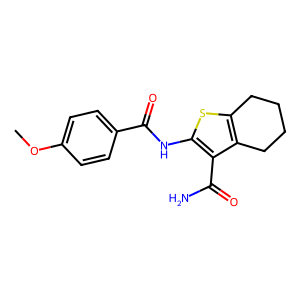

In [ ]:
from  rdkit  import  Chem
from  rdkit.Chem  import  Draw

mol  =  Chem.MolFromSmiles("COc1ccc(C(=O)Nc2sc3c(c2C(N)=O)CCCC3)cc1")
Draw.MolToImage(mol)
#5/5 geçerli molekül üretildi (200 denemede).
#Cc1cccc(CNC(=O)[C@@H]2CCCN2C(=O)C(N)C(c2ccccc2)c2ccccc2)c1
#  → QED: 0.59, MW: 441.6 → ✅ Uygun

#CCc1cc2c(Nc3c[nH]nc3C(=O)Nc3ccc(CN4CCOCC4)cc3)ncnc2cc1OC
#  → QED: 0.34, MW: 487.6 → ❌ Uygunsuz

#Cc1cccc(NC(=O)Nc2ccc(-c3cccc4c3c(N)nn4C)c(C)c2)c1
#  → QED: 0.46, MW: 385.5 → ❌ Uygunsuz

#COc1ccc(/C=C/C(=O)Nc2sc3c(c2C(N)=O)CCCC3)cc1
  #→ QED: 0.81, MW: 356.4 → ✅ Uygun
  #COc1ccc(C(=O)Nc2sc3c(c2C(N)=O)CCCC3)cc1
  #→ QED: 0.90, MW: 330.4 → ✅ Uygun

#Cc1sc2nc(N)[nH]c(=O)c2c1Sc1ccc(Cl)cc1
  #→ QED: 0.75, MW: 323.8 → ✅ Uygun

In [ ]:
from google.colab import drive
drive.mount('/content/drive')